In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("anime.csv")

df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [3]:
df.shape

(12294, 7)

In [4]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [5]:
df.shape

(12294, 7)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  str    
 2   genre     12232 non-null  str    
 3   type      12269 non-null  str    
 4   episodes  12294 non-null  str    
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 1.3 MB


In [7]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [8]:
df.describe(include='object')

,name,genre,type,episodes
count,12294,12232,12269,12294
unique,12292,3264,6,187
top,Saru Kani Gassen,Hentai,TV,1
freq,2,823,3787,5677


In [9]:
df.columns

Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='str')

In [10]:
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [11]:
# Fill missing genre and type
df['genre'] = df['genre'].fillna('Unknown')
df['type'] = df['type'].fillna('Unknown')

# Fill missing rating with median
df['rating'] = df['rating'].fillna(df['rating'].median())

In [12]:
# Convert episodes to numeric
# "Unknown" values will become NaN
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')

# Check how many NaN values were created
df['episodes'].isnull().sum()

np.int64(340)

In [13]:
# Check median
df['episodes'].median()

np.float64(2.0)

In [14]:
# Fill missing episodes with median
df['episodes'] = df['episodes'].fillna(df['episodes'].median())

In [15]:
df.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df['name'].duplicated().sum()

np.int64(2)

In [18]:
# Display anime having duplicate names
df[df['name'].duplicated(keep=False)].sort_values('name')

,anime_id,name,genre,type,episodes,rating,members
10140,22399,Saru Kani Gassen,Kids,OVA,1.0,5.23,62
10141,30059,Saru Kani Gassen,Drama,Movie,1.0,4.75,76
10193,33193,Shi Wan Ge Leng Xiaohua,"Comedy, Parody",ONA,12.0,6.67,114
10194,33195,Shi Wan Ge Leng Xiaohua,"Action, Adventure, Comedy, Fantasy, Parody",Movie,1.0,7.07,110


Duplicate anime names represent different anime records with different anime_id, genre, type, etc. Therefore, these records are retained.

In [19]:
df.describe()

,anime_id,episodes,rating,members
count,12294.000000,12294.000000,12294.000000,1.229400e+04
mean,14058.221653,12.095412,6.475700,1.807134e+04
std,11455.294701,46.244062,1.017179,5.482068e+04
min,1.000000,1.000000,1.670000,5.000000e+00
25%,3484.250000,1.000000,5.900000,2.250000e+02
50%,10260.500000,2.000000,6.570000,1.550000e+03
75%,24794.500000,12.000000,7.170000,9.437000e+03
max,34527.000000,1818.000000,10.000000,1.013917e+06


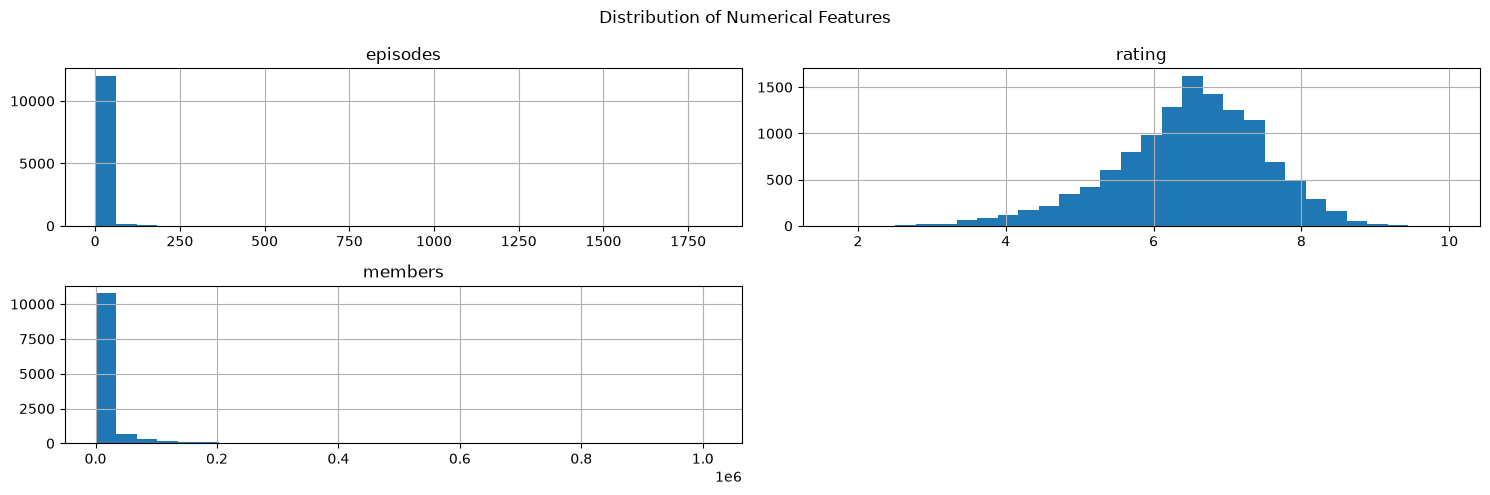

In [20]:
numeric_cols = ['episodes', 'rating', 'members']

df[numeric_cols].hist(figsize=(15, 5), bins=30)

plt.suptitle('Distribution of Numerical Features')
plt.tight_layout()
plt.show()

episodes — highly right-skewed. The median is only 2 episodes, while the maximum is 1818. Most anime have relatively few episodes, but a few long-running anime create a very long right tail.
members — also highly right-skewed. The median is only 1,550 members, while the maximum is over 1 million. A small number of extremely popular anime dominate this variable.
rating — fairly well distributed. It is centered around roughly 6–7, and the histogram looks reasonably close to a bell-shaped distribution. I would not transform rating.

In [21]:
# Check skewness of numerical features

df[['episodes', 'rating', 'members']].skew()

episodes    23.685908
rating      -0.553879
members      6.682934
dtype: float64

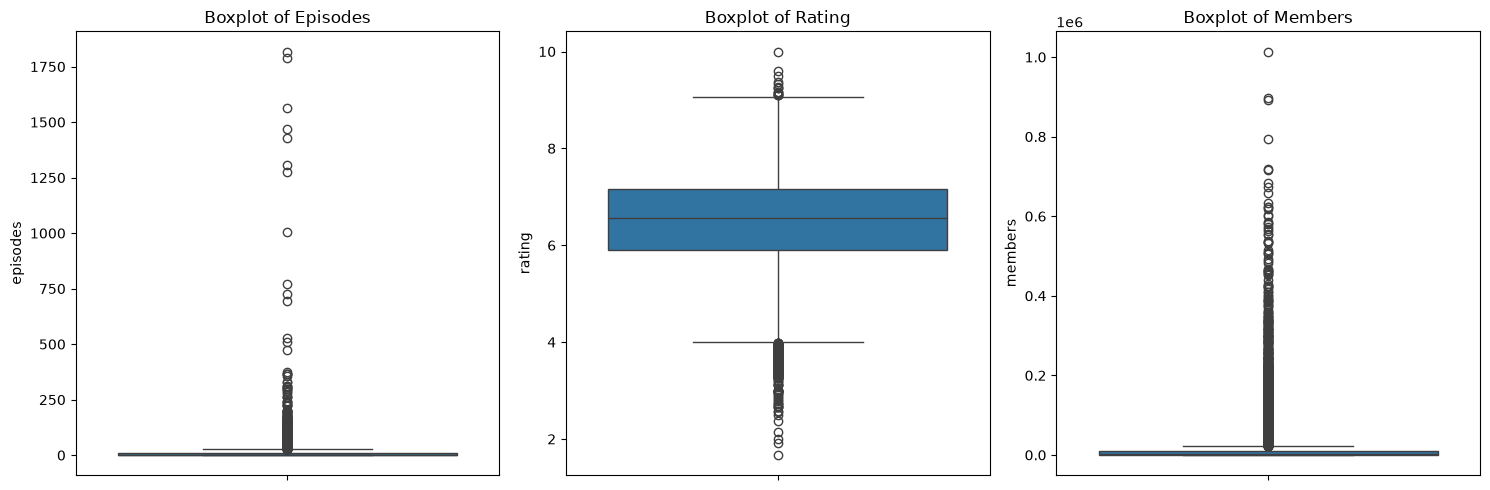

In [22]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['episodes'])
plt.title('Boxplot of Episodes')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['rating'])
plt.title('Boxplot of Rating')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['members'])
plt.title('Boxplot of Members')

plt.tight_layout()
plt.show()

In [23]:
# Apply log transformation to highly skewed features

df['episodes_log'] = np.log1p(df['episodes'])
df['members_log'] = np.log1p(df['members'])

In [24]:
print("Episodes skewness before:", df['episodes'].skew())
print("Episodes skewness after :", df['episodes_log'].skew())

print()

print("Members skewness before:", df['members'].skew())
print("Members skewness after :", df['members_log'].skew())

Episodes skewness before: 23.685908203718704
Episodes skewness after : 1.053521529720933

Members skewness before: 6.68293432180379
Members skewness after : 0.2660955721578259


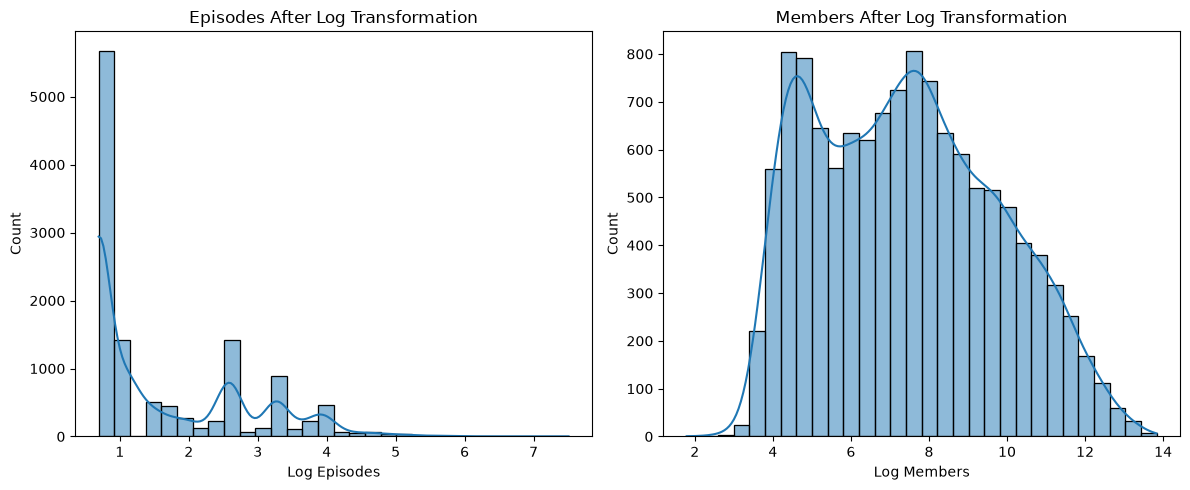

In [25]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['episodes_log'], bins=30, kde=True)
plt.title('Episodes After Log Transformation')
plt.xlabel('Log Episodes')

plt.subplot(1, 2, 2)
sns.histplot(df['members_log'], bins=30, kde=True)
plt.title('Members After Log Transformation')
plt.xlabel('Log Members')

plt.tight_layout()
plt.show()

episodes and members were highly positively skewed. Log transformation was applied to reduce the skewness. The distribution of members improved significantly, while episodes remained right-skewed due to the naturally large variation in the number of episodes across anime. rating was not transformed because its distribution showed only moderate skewness.

In [26]:
# Count of each anime type
df['type'].value_counts()

type
TV         3787
OVA        3311
Movie      2348
Special    1676
ONA         659
Music       488
Unknown      25
Name: count, dtype: int64

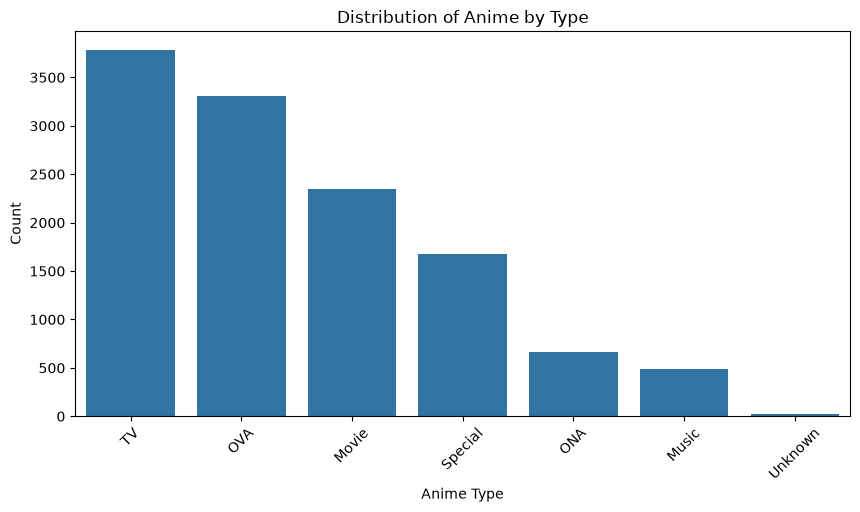

In [27]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='type',
    order=df['type'].value_counts().index
)

plt.title('Distribution of Anime by Type')
plt.xlabel('Anime Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

TV anime are the most common type in the dataset, followed by OVA and Movies. ONA and Music anime are comparatively less frequent. Only a very small number of records have an unknown type.

In [28]:
df['genre'].value_counts()

genre
Hentai                                                  823
Comedy                                                  523
Music                                                   301
Kids                                                    199
Comedy, Slice of Life                                   179
                                                       ... 
Action, Comedy, Demons, Hentai, Martial Arts, School      1
Action, Comedy, Hentai, Romance, Supernatural             1
Hentai, Sports                                            1
Drama, Romance, School, Yuri                              1
Hentai, Slice of Life                                     1
Name: count, Length: 3265, dtype: int64

In [29]:
# Split multiple genres and convert them into individual rows
genre_counts = (
    df['genre']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
)

genre_counts.head(15)

genre
Comedy           4645
Action           2845
Adventure        2348
Fantasy          2309
Sci-Fi           2070
Drama            2016
Shounen          1712
Kids             1609
Romance          1464
School           1220
Slice of Life    1220
Hentai           1141
Supernatural     1037
Mecha             944
Music             860
Name: count, dtype: int64

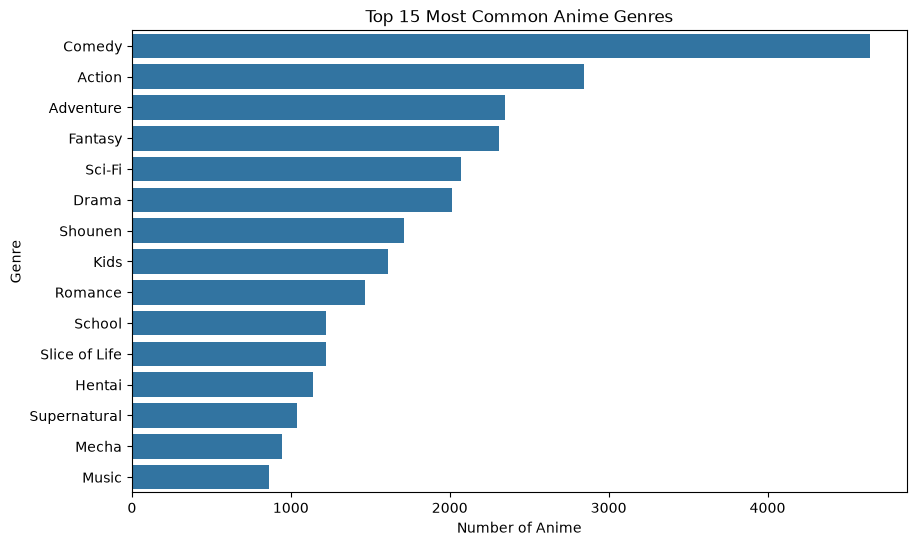

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=genre_counts.head(15).values,
    y=genre_counts.head(15).index
)

plt.title('Top 15 Most Common Anime Genres')
plt.xlabel('Number of Anime')
plt.ylabel('Genre')

plt.show()

Comedy is the most frequently occurring genre in the dataset, followed by Action and Adventure. Fantasy, Sci-Fi, and Drama are also common. Since an anime can belong to multiple genres, individual genres were separated before calculating their frequencies.

In [31]:
# Top 10 highest-rated anime with at least 1000 members

top_rated = (
    df[df['members'] >= 1000]
    .sort_values('rating', ascending=False)
    .head(10)
)

top_rated[['name', 'rating', 'members']]

,name,rating,members
0,Kimi no Na wa.,9.37,200630
1,Fullmetal Alchemist: Brotherhood,9.26,793665
2,Gintama°,9.25,114262
3,Steins;Gate,9.17,673572
4,Gintama&#039;,9.16,151266
5,Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...,9.15,93351
6,Hunter x Hunter (2011),9.13,425855
7,Ginga Eiyuu Densetsu,9.11,80679
9,Gintama&#039;: Enchousen,9.11,81109
8,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,9.10,72534


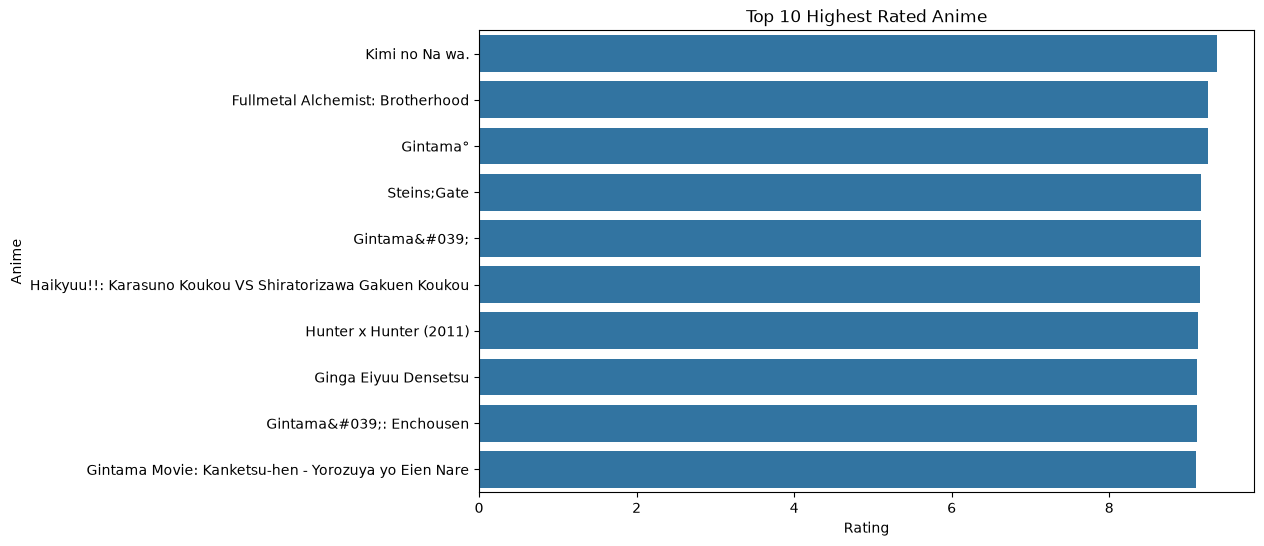

In [32]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_rated,
    x='rating',
    y='name'
)

plt.title('Top 10 Highest Rated Anime')
plt.xlabel('Rating')
plt.ylabel('Anime')

plt.show()

In [33]:
# Top 10 most popular anime

top_popular = (
    df.sort_values('members', ascending=False)
    .head(10)
)

top_popular[['name', 'members', 'rating']]

,name,members,rating
40,Death Note,1013917,8.71
86,Shingeki no Kyojin,896229,8.54
804,Sword Art Online,893100,7.83
1,Fullmetal Alchemist: Brotherhood,793665,9.26
159,Angel Beats!,717796,8.39
19,Code Geass: Hangyaku no Lelouch,715151,8.83
841,Naruto,683297,7.81
3,Steins;Gate,673572,9.17
445,Mirai Nikki (TV),657190,8.07
131,Toradora!,633817,8.45


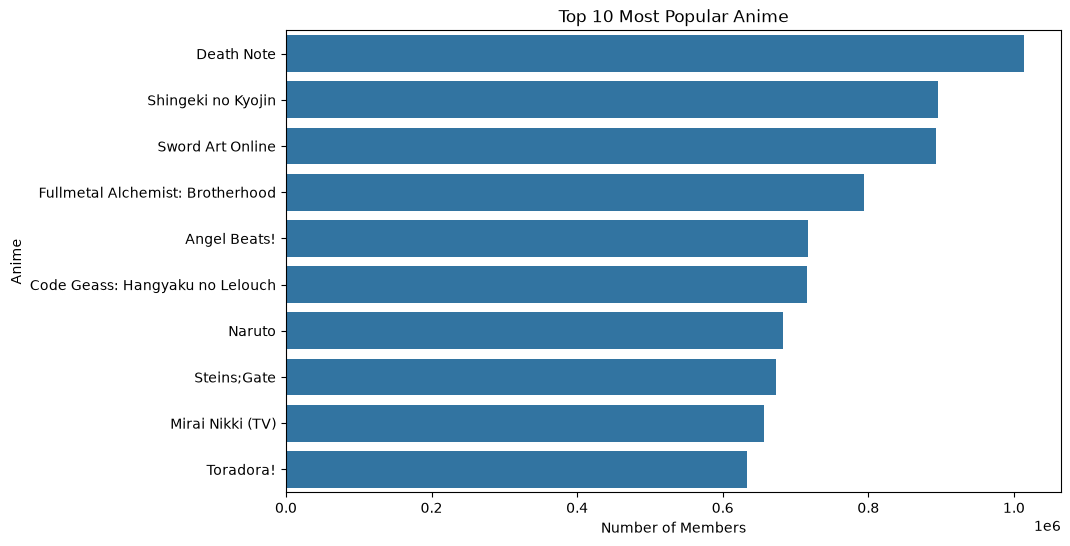

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_popular,
    x='members',
    y='name'
)

plt.title('Top 10 Most Popular Anime')
plt.xlabel('Number of Members')
plt.ylabel('Anime')

plt.show()

The highest-rated anime include Kimi no Na wa., Fullmetal Alchemist: Brotherhood, Gintama°, and Steins;Gate. In terms of popularity, Death Note has the highest number of members, followed by Shingeki no Kyojin and Sword Art Online. This shows that the highest-rated anime are not necessarily the most popular anime.

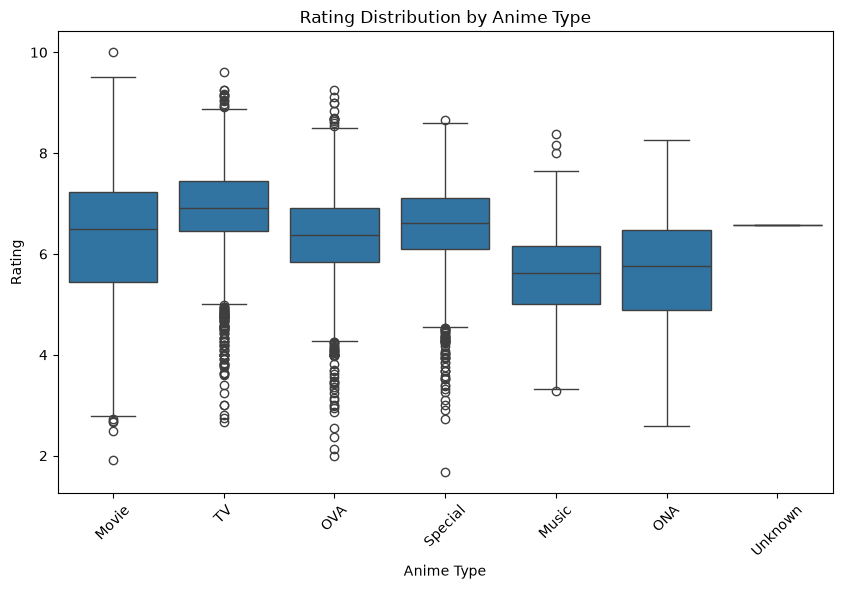

In [35]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='type',
    y='rating'
)

plt.title('Rating Distribution by Anime Type')
plt.xlabel('Anime Type')
plt.ylabel('Rating')
plt.xticks(rotation=45)

plt.show()

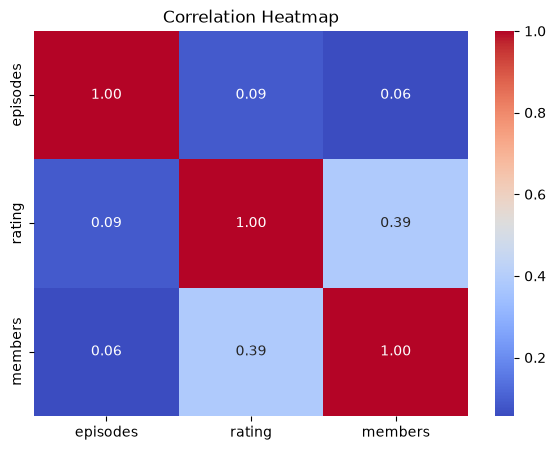

In [36]:
numeric_df = df[['episodes', 'rating', 'members']]

plt.figure(figsize=(7, 5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

Ratings and number of members show a moderate positive correlation (0.39), suggesting that more popular anime tend to have somewhat higher ratings. The number of episodes has very little correlation with either rating or popularity.

In [37]:
#Create the content feature
# Combine genre and type into a single content feature

df['content'] = (
    df['genre'].fillna('') + ' ' +
    df['type'].fillna('')
)

df[['name', 'genre', 'type', 'content']].head()

,name,genre,type,content
0,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,"Drama, Romance, School, Supernatural Movie"
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,"Action, Adventure, Drama, Fantasy, Magic, Mili..."
2,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,"Action, Comedy, Historical, Parody, Samurai, S..."
3,Steins;Gate,"Sci-Fi, Thriller",TV,"Sci-Fi, Thriller TV"
4,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,"Action, Comedy, Historical, Parody, Samurai, S..."


In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(df['content'])

tfidf_matrix.shape

(12294, 52)

In [39]:
df = df.reset_index(drop=True)

In [40]:
indices = pd.Series(df.index, index=df['name'])

indices.head()

name
Kimi no Na wa.                      0
Fullmetal Alchemist: Brotherhood    1
Gintama°                            2
Steins;Gate                         3
Gintama&#039;                       4
dtype: int64

In [41]:
from sklearn.metrics.pairwise import cosine_similarity

In [42]:
def recommend_anime(title, n=10):

    # Check if anime exists
    if title not in indices.index:
        return "Anime not found. Please check the spelling."

    # Get index of selected anime
    idx = indices[title]

    # Handle duplicate anime names
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]

    # Calculate cosine similarity
    sim_scores = cosine_similarity(
        tfidf_matrix[idx],
        tfidf_matrix
    ).flatten()

    # Sort by similarity score from highest to lowest
    similar_indices = sim_scores.argsort()[::-1]

    # Remove selected anime itself and take top n
    similar_indices = [
        i for i in similar_indices
        if i != idx
    ][:n]

    # Create recommendation dataframe
    recommendations = df.iloc[similar_indices][
        ['name', 'genre', 'type', 'rating', 'members']
    ].copy()

    # Add similarity score
    recommendations['similarity_score'] = sim_scores[similar_indices]

    return recommendations.reset_index(drop=True)

In [43]:
recommend_anime('Naruto')

,name,genre,type,rating,members,similarity_score
0,Naruto: Shippuuden,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,7.94,533578,1.000000
1,Naruto x UT,"Action, Comedy, Martial Arts, Shounen, Super P...",OVA,7.58,23465,0.952814
2,Rekka no Honoo,"Action, Adventure, Martial Arts, Shounen, Supe...",TV,7.44,35258,0.949496
3,Boruto: Naruto the Movie,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,8.03,74690,0.945317
4,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.50,83515,0.945317
5,Naruto: Shippuuden Movie 4 - The Lost Tower,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.53,84527,0.945317
6,Naruto Soyokazeden Movie: Naruto to Mashin to ...,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.11,25174,0.945317
7,Wolverine,"Action, Martial Arts, Super Power",TV,6.24,14989,0.939496
8,Kurokami The Animation,"Action, Martial Arts, Super Power",TV,7.29,72750,0.939496
9,Project ARMS,"Action, Martial Arts, Super Power",TV,7.15,6903,0.939496


In [44]:
def recommend_anime(title, n=10):

    if title not in indices.index:
        return "Anime not found. Please check the spelling."

    idx = indices[title]

    # Handle duplicate names
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]

    # Calculate similarity
    sim_scores = cosine_similarity(
        tfidf_matrix[idx],
        tfidf_matrix
    ).flatten()

    # Create temporary dataframe
    recommendations = df.copy()
    recommendations['similarity_score'] = sim_scores

    # Remove selected anime
    recommendations = recommendations.drop(index=idx)

    # Sort by similarity first, then rating
    recommendations = recommendations.sort_values(
        by=['similarity_score', 'rating'],
        ascending=[False, False]
    )

    return recommendations[
        ['name', 'genre', 'type', 'rating',
         'members', 'similarity_score']
    ].head(n).reset_index(drop=True)

In [45]:
recommend_anime('Naruto')

,name,genre,type,rating,members,similarity_score
0,Naruto: Shippuuden,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,7.94,533578,1.000000
1,Naruto x UT,"Action, Comedy, Martial Arts, Shounen, Super P...",OVA,7.58,23465,0.952814
2,Rekka no Honoo,"Action, Adventure, Martial Arts, Shounen, Supe...",TV,7.44,35258,0.949496
3,Boruto: Naruto the Movie,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,8.03,74690,0.945317
4,Naruto: Shippuuden Movie 4 - The Lost Tower,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.53,84527,0.945317
5,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.50,83515,0.945317
6,Naruto Soyokazeden Movie: Naruto to Mashin to ...,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.11,25174,0.945317
7,Kurokami The Animation,"Action, Martial Arts, Super Power",TV,7.29,72750,0.939496
8,Project ARMS,"Action, Martial Arts, Super Power",TV,7.15,6903,0.939496
9,Wolverine,"Action, Martial Arts, Super Power",TV,6.24,14989,0.939496


In [46]:
recommend_anime('Death Note')

,name,genre,type,rating,members,similarity_score
0,Mousou Dairinin,"Drama, Mystery, Police, Psychological, Superna...",TV,7.74,137687,0.968911
1,Death Note Rewrite,"Mystery, Police, Psychological, Supernatural, ...",Special,7.84,88699,0.944472
2,Higurashi no Naku Koro ni Kai,"Mystery, Psychological, Supernatural, Thriller",TV,8.41,218101,0.884548
3,Mirai Nikki (TV),"Action, Mystery, Psychological, Shounen, Super...",TV,8.07,657190,0.822997
4,Higurashi no Naku Koro ni Rei,"Comedy, Mystery, Psychological, Supernatural, ...",OVA,7.56,99463,0.820930
5,Higurashi no Naku Koro ni,"Horror, Mystery, Psychological, Supernatural, ...",TV,8.17,359494,0.802674
6,Monster,"Drama, Horror, Mystery, Police, Psychological,...",TV,8.72,247562,0.797930
7,Mirai Nikki (TV): Ura Mirai Nikki,"Action, Comedy, Mystery, Psychological, Shoune...",Special,6.79,32565,0.754272
8,Zankyou no Terror,"Psychological, Thriller",TV,8.26,342893,0.732177
9,Shigofumi,"Drama, Fantasy, Psychological, Supernatural, T...",TV,7.62,54000,0.729279
